Saving student_habits_performance.csv to student_habits_performance.csv

Total dataset size: 1000
Training data size: 700
Testing data size: 300

********************************
    Experiment Configuration
********************************

Test Size: 30%
Epochs: 50
Batch Size: 10

*************************
   Logistic Regression
*************************

Training time (s): 0.016
Accuracy: 0.79
Confusion matrix:

 [[117  30]
 [ 33 120]]

*************************
	  Random Forest
*************************

Training time (s): 1.216
Accuracy: 0.7567
Confusion matrix:

 [[115  32]
 [ 41 112]]

*************************
	  Neural Network
*************************

Training time (s): 14.757
Accuracy: 0.7967
Confusion matrix:

 [[117  30]
 [ 31 122]]


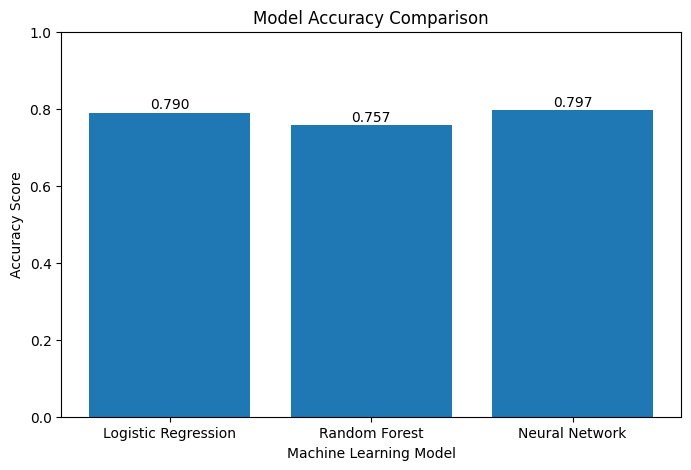

In [ ]:
'''
Name: Saul Evora
Assignment: Term Project
Title: "Evaluating the Accuracy of Predicting Student Exam Performances Using Machine Learning Models"
'''

# The time library is used to keep track of the models' training time in seconds

import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow import keras

# ***********************
# Loading dataset
# ***********************

def load_dataset_man():
    from google.colab import files
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
    df = pd.read_csv(file_name)
    return df

def load_dataset_auto():
    from google.colab import drive
    drive.mount('/content/drive')

    df = pd.read_csv('/content/drive/Data Mining ML Project/student_habits_performance.csv')

# **********************************
# Selected columns from the dataset
# **********************************

'''
This section allows users to select their attributes without needing to
MANUALLY remove the attributes from thier datasets.

The following selections are based on the attributes from
the dataset "student_habits_performance.csv."
'''

def select_columns(df):
    selected_columns = [
        "student_id", #Later dropped because it has no effect on predictions
        "age",
        "study_hours_per_day",
        "part_time_job",
        "attendance_percentage",
        "sleep_hours",
        "exam_score" #Used for target variable, but later dropped to prevent data leakage
    ]
    df = df[selected_columns].copy()
    return df

# *************************************
# Create binary target from exam_score
# *************************************

# Pass = 1 if exam_score >= 70, otherwise Fail = 0

def create_target(df):
    df["target"] = (df["exam_score"] >= 70).astype(int)
    return df

# *********************************
# Define input features and target
# *********************************
'''
Attributes "student_id", "exam_score" and "target" are dropped.
Why?

    1. student_id is just an identifier and has no effect in the prediction.

    2. Values within the exam_score are converted to binary targets and would
       need to dropped to prevent data leakage.

    3. target had to be moved to y to prevent the models from knowing the target
       values.

'''

def define_features_target(df):
    X = df.drop(columns=["student_id", "exam_score", "target"])
    y = df["target"]
    return X, y

# ****************************
# Identify feature types
# ****************************

def identify_feature_types(X):
    numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = [c for c in X.columns if c not in numeric_features]
    return numeric_features, categorical_features

# ****************************
# Preprocessing
# ****************************

def build_preprocessor(numeric_features, categorical_features):
    preprocess = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ],
        remainder="drop"
    )
    return preprocess

# ****************************
# Train/test split
# ****************************

def split_data(X, y, test_size_value):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size_value,
        random_state=0,
        stratify=y
    )
    return X_train, X_test, y_train, y_test

# ************************************
# Print dataset and configuration info
# ************************************
def print_dataset_info(df, X_train, X_test, test_size_value, epochs_value, batch_size_value):
    print("\nTotal dataset size:", len(df))
    print("Training data size:", len(X_train))
    print("Testing data size:", len(X_test))

    print("\n"+"*" * 32)
    print("    Experiment Configuration")
    print("*" * 32 + "\n")

    print(f"Test Size: {int(test_size_value * 100)}%")
    print(f"Epochs: {epochs_value}")
    print(f"Batch Size: {batch_size_value}")

# ****************************
# Logistic Regression
# ****************************
def run_logistic_regression(preprocess, X_train, X_test, y_train, y_test):
    logreg = Pipeline(steps=[
        ("preprocess", preprocess),

    # The following code contains hyperparatmer tuning for LR ML model
    # so users can adjust for better optimization

    #("model", LogisticRegression(max_iter=2000, solver="saga"))

    #Solver settings -> "lbfgs", "liblinear" or "saga"

        ("model", LogisticRegression(max_iter=2000, solver="saga"))
    ])

    t0 = time.time()
    logreg.fit(X_train, y_train)
    t_logreg = time.time() - t0

    pred_logreg = logreg.predict(X_test)
    logreg_accuracy = accuracy_score(y_test, pred_logreg)

    print("\n"+"*" * 25)
    print("   Logistic Regression")
    print("*" * 25 + "\n")

    print("Training time (s):", round(t_logreg, 3))
    print("Accuracy:", round(logreg_accuracy, 4))
    print("Confusion matrix:\n\n", confusion_matrix(y_test, pred_logreg))
    #print("\nClassification report:\n\n", classification_report(y_test, pred_logreg))

    return logreg_accuracy

# ****************************
# Random Forest
# ****************************
def run_random_forest(preprocess, X_train, X_test, y_train, y_test):
    rf = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(

            # The following code contains hyperparatmer tuning for RF ML model
            # so users can adjust for better optimization

            #n_estimators=500, <- Original setting
            n_estimators=500,
            random_state=0,
            n_jobs=-1
        ))
    ])

    t0 = time.time()
    rf.fit(X_train, y_train)
    t_rf = time.time() - t0

    pred_rf = rf.predict(X_test)
    rf_accuracy = accuracy_score(y_test, pred_rf)

    print("\n"+"*" * 25)
    print("\t  Random Forest")
    print("*" * 25 + "\n")

    print("Training time (s):", round(t_rf, 3))
    print("Accuracy:", round(rf_accuracy, 4))
    print("Confusion matrix:\n\n", confusion_matrix(y_test, pred_rf))
    #print("\nClassification report:\n\n", classification_report(y_test, pred_rf))

    return rf_accuracy

# ****************************
# Neural Network
# ****************************

'''
All epochs and batch size config are in the main method!!!

        Batch size vs Epochs?

        For example:

            epochs_value = 50
            batch_size_value = 10

         1. If the epochs value is 50, then Neural Network model will train on the
            entire dataset 50 times.

         2. If the batch size value is 10, then the model will train on
            10 observations from the dataset at a time.
         '''

def run_neural_network(preprocess, X_train, X_test, y_train, y_test, epochs_value, batch_size_value):
    X_train_nn = preprocess.fit_transform(X_train)
    X_test_nn = preprocess.transform(X_test)

    if hasattr(X_train_nn, "toarray"):
        X_train_nn = X_train_nn.toarray()
        X_test_nn = X_test_nn.toarray()

    input_dim = X_train_nn.shape[1]

    nn = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(20, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(20, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(20, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid")
    ])

    nn.compile(
        loss="binary_crossentropy",
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        metrics=["accuracy"]
    )

    t0 = time.time()
    history = nn.fit(
        X_train_nn,
        y_train.values,


        #All epochs and batch size config are in the main method!!!

        epochs=epochs_value,
        batch_size=batch_size_value,
        validation_data=(X_test_nn, y_test.values),
        verbose=0
    )
    t_nn = time.time() - t0

    prob_nn = nn.predict(X_test_nn, verbose=0).ravel()
    pred_nn = (prob_nn >= 0.5).astype(int)
    nn_accuracy = accuracy_score(y_test, pred_nn)

    print("\n"+"*" * 25)
    print("\t  Neural Network")
    print("*" * 25 + "\n")

    print("Training time (s):", round(t_nn, 3))
    print("Accuracy:", round(nn_accuracy, 4))
    print("Confusion matrix:\n\n", confusion_matrix(y_test, pred_nn))
    #print("\nClassification report:\n\n", classification_report(y_test, pred_nn))

    return nn_accuracy

# ****************************
# Accuracy Comparison Graph
# ****************************

def plot_accuracy_graph(logreg_accuracy, rf_accuracy, nn_accuracy):
    models = ["Logistic Regression", "Random Forest", "Neural Network"]
    accuracies = [logreg_accuracy, rf_accuracy, nn_accuracy]

    plt.figure(figsize=(8, 5))
    plt.bar(models, accuracies)

    plt.title("Model Accuracy Comparison")
    plt.xlabel("Machine Learning Model")
    plt.ylabel("Accuracy Score")
    plt.ylim(0, 1)

    for i, v in enumerate(accuracies):
        plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

    plt.show()

# ****************************
# Main method
# ****************************
def main():
    '''
    Experiment settings

    test_size_value = 0.2 <- Original setting
    test_size_value = 0.3 <- Optimal setting

    epochs=10, <- Original setting
    batch_size=10, <- Original setting
    epochs=30, <- Default setting
    batch_size=10, <- Defaul setting

    Shows the total amount of rows in the CSV file, and much are used for training and training
    Adjust the amount of training and testing in the following code:

    test_size_value = 0.3

    The example code shows the models are set to train with .8 (which is 80 percent) of the dataset
    and then tested using the test size of .2 (20 percent) of the dataset. The test size can be
    adjusted up to LESS than 1 (100 percent)
    '''

    test_size_value = 0.3
    epochs_value = 50
    batch_size_value = 10

    # Run project steps

    # Uncomment the following code if you want to MANUALLY select the file
    # in your computer.

    df = load_dataset_man()

    # Uncomment the following code if you want to ALLOW Google have
    # FULL ACCESS to your Google Drive by simply entering the file directory.

    #df = load_dataset_auto()

    #Data prepropressing phases

    df = select_columns(df)
    df = create_target(df)

    X, y = define_features_target(df)
    numeric_features, categorical_features = identify_feature_types(X)
    preprocess = build_preprocessor(numeric_features, categorical_features)

    X_train, X_test, y_train, y_test = split_data(X, y, test_size_value)

    print_dataset_info(df, X_train, X_test, test_size_value, epochs_value, batch_size_value)

    #Calling Logistic Regression model

    logreg_accuracy = run_logistic_regression(preprocess, X_train, X_test, y_train, y_test)

    #Calling Random Forest model

    rf_accuracy = run_random_forest(preprocess, X_train, X_test, y_train, y_test)

    #Calling Neural Network model

    nn_accuracy = run_neural_network(preprocess, X_train, X_test, y_train, y_test, epochs_value, batch_size_value)

    plot_accuracy_graph(logreg_accuracy, rf_accuracy, nn_accuracy)


# ****************************
# Program start
# ****************************
if __name__ == "__main__":
    main()